In [2]:
import seaborn as sns

from assembly_designer.workflow.workflow import LiquidHandlingWorkflow
from assembly_designer.manager.manager import AssemblyWorkflowManager
from assembly_designer.mtp_manager.mtp_manager import MTPManager
from assembly_designer.utils import find_planning_file

import logging
logging.basicConfig(level=logging.INFO)

In [3]:
# Meta data

type_of_molbiowork="Gibson"
try:
    file = find_planning_file(r".", "assembly")
except:
    file = "Automated_assembly_designer_V01.xlsx"

sheet_name="Plan+"

In [4]:
# Initialize with Golden Gate template
mtp_manager = MTPManager(default_template=type_of_molbiowork)

# List MTPs for Golden Gate
print("Template MTPs:", mtp_manager.list_mtps())

# # Access a specific MTP
# mtp = mtp_manager.get_mtp("mtp_source")

# # Switch to PCR template
# mtp_manager.switch_template("Golden Gate")
# print("PCR template MTPs:", mtp_manager.list_mtps())

Template MTPs: ['mtp_source', 'mtp_destination', 'master_mix', 'mtp_mastermix', 'mtp_dna_stocks', 'water']


In [ ]:
# Initialize Workflow

# This cell defines the liquid handling workflow steps for MoClo assembly.
# Each workflow.add_step() call corresponds to a worklist file that will be generated.
#
# KEY PARAMETERS EXPLAINED:
# - sample_handling: "transfer" (move samples to specific wells) or "sample_distribution" (distribute to multiple wells)
# - start: "Yes" (first operation on this plate, initializes volumes) or "No" (subsequent operation)
# - additional_liquid_factor: Multiplier for extra volume (e.g., 1.1 = 10% extra for pipetting safety)
# - fake_source_plate: For simulation when source isn't a real plate


# ADJUST THIS WORKFLOW BASED ON YOUR EXCEL PLANNING FILE
# - Uncomment/comment steps based on parts in your assembly (e.g., if no Signal Peptide, keep it commented)
workflow = LiquidHandlingWorkflow()

workflow.add_step(
    process_label="Worklist_W",
    source_plate="water",
    destination_plate="mtp_source", # look @mtp_manager.list_mtps() which plate names there are: :)
    liquid_handling="Water to dilute",
    sample_handling="transfer",
    start = "Yes", #"Yes"/"No" --> important for liquid handling simulation. filling initial volumes in the simulation. Yes if in that plate the first liquid handling operation appear with that worklist
    additional_liquid_factor = 1.1,
)
workflow.add_step(
    process_label="Worklist_DNA",
    source_plate="mtp_dna_stocks",
    destination_plate="mtp_source",
    liquid_handling="DNA parts for dilution",
    sample_handling="transfer",
    start = "Yes",
    additional_liquid_factor = 1.1,
)
# workflow.add_step(
#     process_label="Worklist_PM_parts",
#     source_plate="mtp_source",
#     destination_plate="mtp_source",
#     liquid_handling="Primermix",
#     sample_handling="transfer",
#     start = "No",
#     additional_liquid_factor = 1.1,
# )
workflow.add_step(
    process_label="Worklist_MM",
    source_plate="mtp_mastermix",
    destination_plate="mtp_destination",
    liquid_handling="Mastermix",
    sample_handling="sample_distribution",
    fake_source_plate="master_mix",
    start = "Yes",
    additional_liquid_factor = 1.1
)
workflow.add_step(
    process_label="Worklist_BB",
    source_plate="mtp_source",
    destination_plate="mtp_destination",
    liquid_handling="Backbone",
    sample_handling="transfer",
    start = "Yes",
    additional_liquid_factor = 1.1,
)
workflow.add_step(
    process_label="Worklist_P",
    source_plate="mtp_source",
    destination_plate="mtp_destination",
    liquid_handling="Promotor",
    sample_handling="transfer",
    start = "No",
    additional_liquid_factor = 1.1
)
# workflow.add_step(
#     process_label="Worklist_RBS",
#     source_plate="mtp_source",
#     destination_plate="mtp_destination",
#     liquid_handling="RBS",
#     sample_handling="transfer",
#     start = "No",
#     additional_liquid_factor = 1.1
# )
# workflow.add_step(
#     process_label="Worklist_SP",
#     source_plate="mtp_source",
#     destination_plate="mtp_destination",
#     liquid_handling="Signal Peptide",
#     sample_handling="transfer",
#     start = "No",
#     additional_liquid_factor = 1.1
# )
workflow.add_step(
    process_label="Worklist_GoI",
    source_plate="mtp_source",
    destination_plate="mtp_destination",
    liquid_handling="Gene of interest",
    sample_handling="transfer",
    start = "No",
    additional_liquid_factor = 1.1
)
# workflow.add_step(
#     process_label="Worklist_Tags",
#     source_plate="mtp_source",
#     destination_plate="mtp_destination",
#     liquid_handling="tags",
#     sample_handling="transfer",
#     start = "No",
#     additional_liquid_factor = 1.1,
# )
# workflow.add_step(
#     process_label="Worklist_PM",
#     source_plate="mtp_source",
#     destination_plate="mtp_destination",
#     liquid_handling="Plasmidmix",
#     sample_handling="sample_distribution",
#     fake_source_plate="master_mix",
#     start = "No",
#     additional_liquid_factor = 1.4
# )
workflow.add_step(
     process_label="Worklist_GG_water",
     source_plate="water",
     destination_plate="mtp_destination",
     liquid_handling="water to fill up final volume",
     sample_handling="transfer",
     start = "No",
     additional_liquid_factor = 1.1,
     )


13:08:39 INFO assembly_designer.workflow.workflow: Added step: Worklist_W
13:08:39 INFO assembly_designer.workflow.workflow: Added step: Worklist_DNA
13:08:39 INFO assembly_designer.workflow.workflow: Added step: Worklist_MM
13:08:39 INFO assembly_designer.workflow.workflow: Added step: Worklist_BB
13:08:39 INFO assembly_designer.workflow.workflow: Added step: Worklist_P
13:08:39 INFO assembly_designer.workflow.workflow: Added step: Worklist_GoI
13:08:39 INFO assembly_designer.workflow.workflow: Added step: Worklist_GG_water


13:08:40 INFO assembly_designer.workflow.workflow: Flowchart saved to results\workflow.png


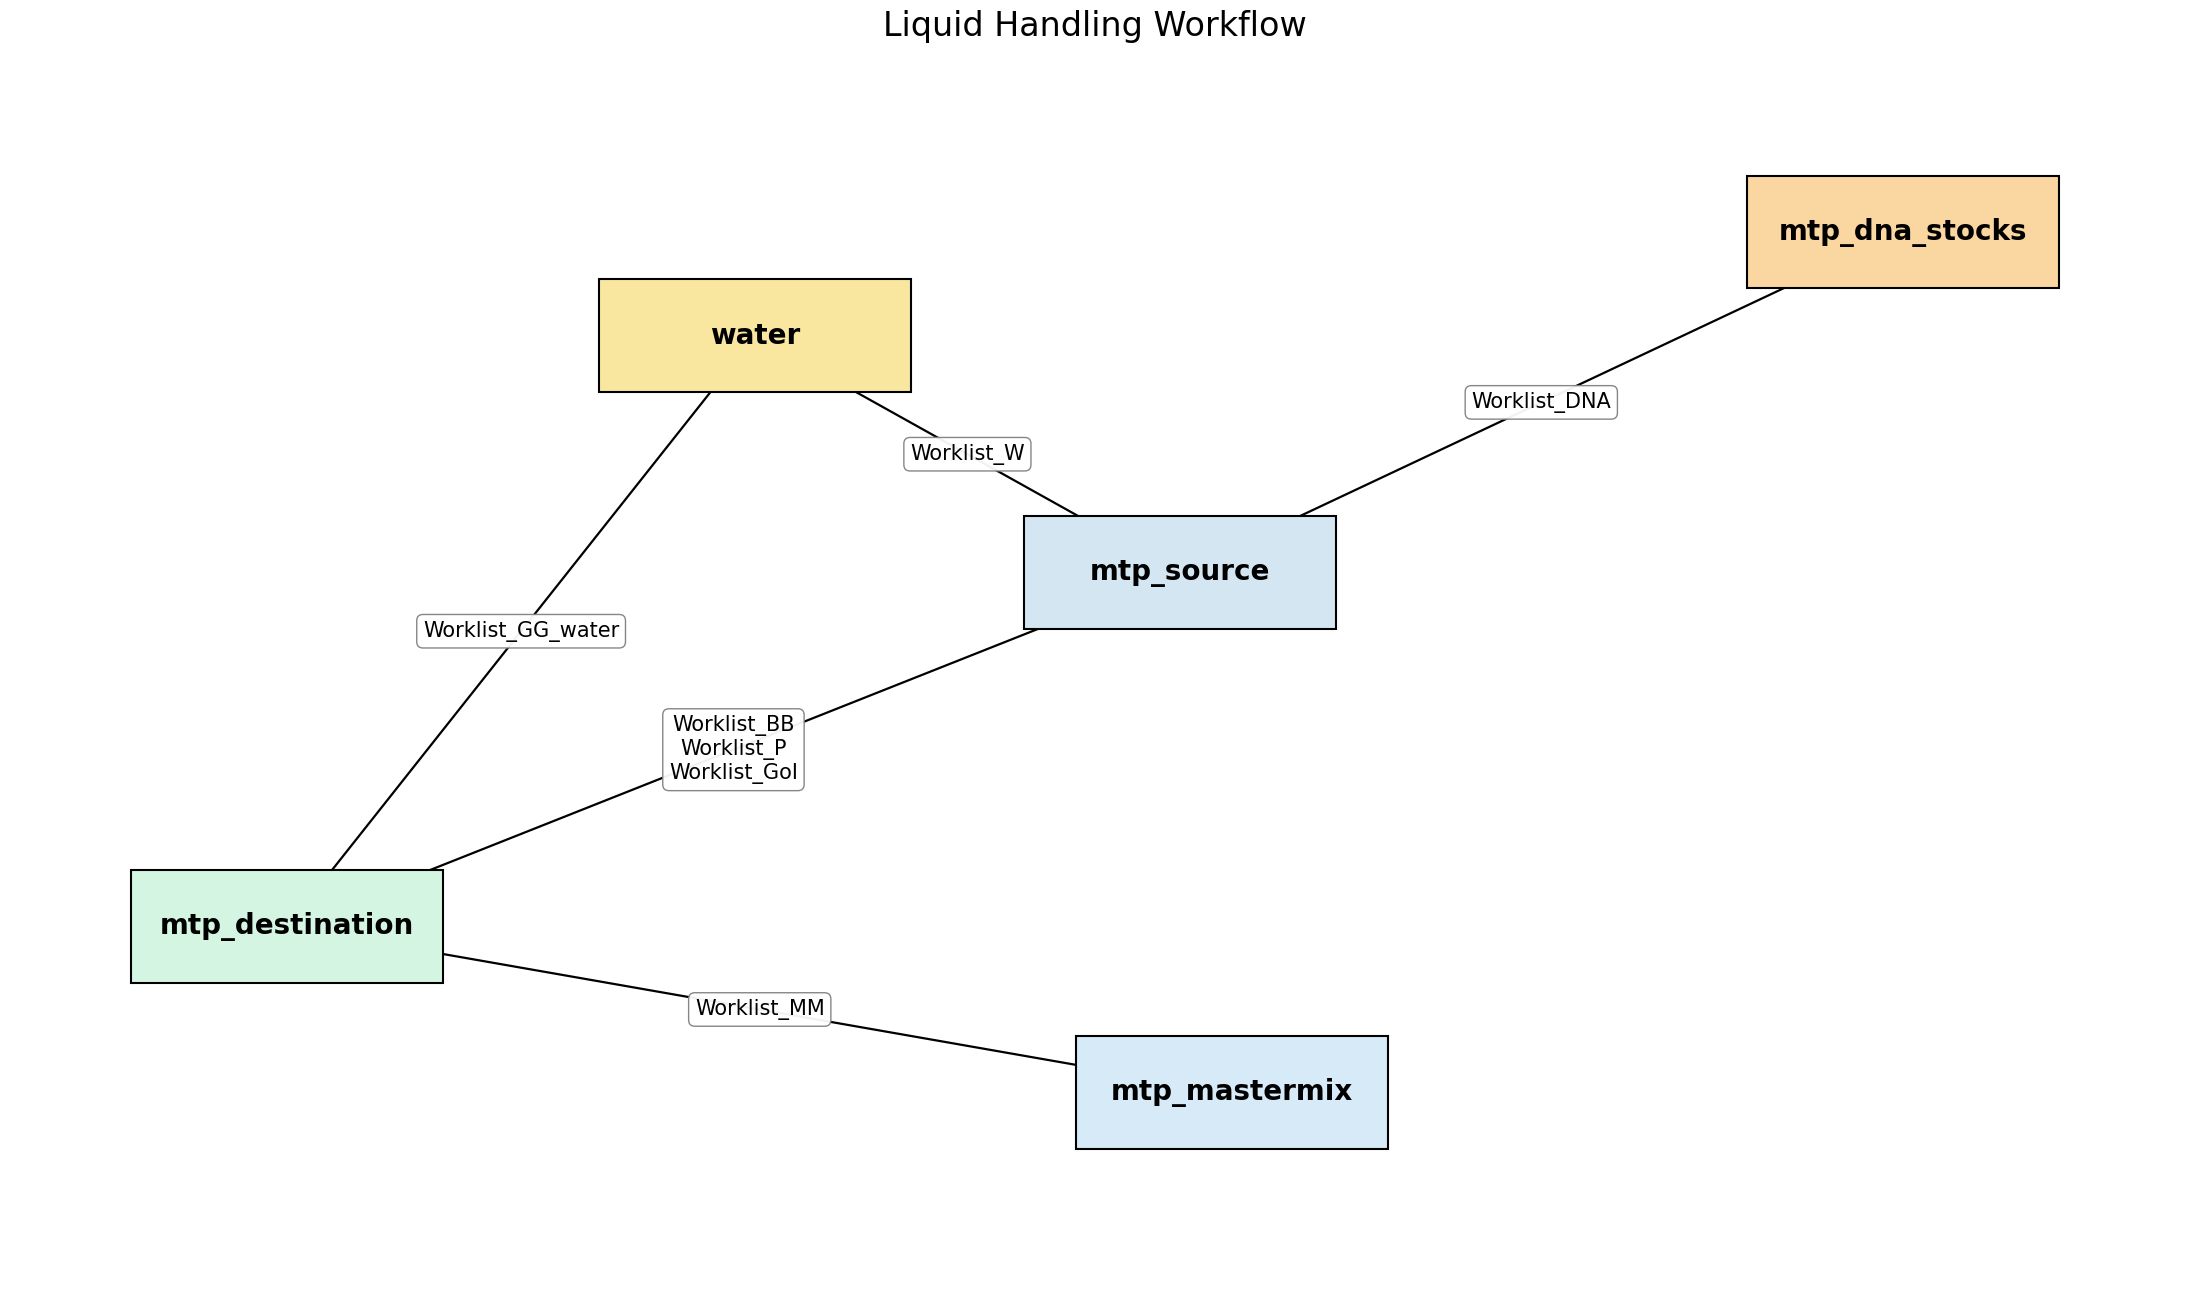

In [6]:
workflow.generate_flowchart(
    save_path="workflow.png",
    export_format="png",
    fig_size=(22.0, 13.0),
    dpi=300,
    font_family="DejaVu Sans",
    node_font_size=20,
    edge_font_size=15,
    title="Liquid Handling Workflow",
    title_font_size=24,
    box_width=4.5,
    box_height=1.8,
    node_facecolor="#CFE2F3",
    node_edgecolor="black",
    node_linewidth=1.5,
    edge_color="black",
    edge_width=1.6,
    arrow_size=22,
    color_by_plate_type=True,
    plate_colors=None,
    label_box_alpha=0.95,
    show_axes=False,
    transparent=False,
    pad_inches=0.4,
    show_plot=True,
    max_labels_per_edge=None,
    spring_k=2.2,
    spring_iterations=400,
    spring_seed=42,
    scale=12.0,
)

In [7]:
# Create AssemblyWorkflowManager
assembly_manager = AssemblyWorkflowManager()

In [8]:
# Initialize Workflow Manager
assembly_manager.initialize(plot=False, 
                            plot_information=False,
                            file_path=file,
                            mtp_manager=mtp_manager,
                            workflow=workflow,
                            sheet_name=sheet_name,
                            type_of_molbiowork=type_of_molbiowork)


13:08:40 INFO assembly_designer.manager.manager: Initializing AssemblyWorkflowManager...
C:\Users\koesters\Sciebo\Git\Repositories\assembly_designer\assembly_designer\manager\manager.py:433: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  norm = sheet_df.applymap(lambda x: str(x).strip().lower() if pd.notna(x) else "")
c:\Users\koesters\AppData\Local\miniforge3\envs\adesigner\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
C:\Users\koesters\Sciebo\Git\Repositories\assembly_designer\assembly_designer\manager\manager.py:2571: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(
13:08:41 INFO assembly_designer.manager.manager: All parts matched correctly.
13:08:41 INFO assembly_designer.manager.manager: Found 12 matching sheet(s): ['Worklist_W', 'Worklist_DNA', 'Worklist_PM_parts', 'Worklist_PM', 'Worklist_

In [9]:
# Process Workflow
assembly_manager.process_workflow(plot=False)

13:08:42 INFO assembly_designer.manager.manager: Processing workflow...
13:08:42 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_W' -> worklist\Worklist_W.csv
13:08:42 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_DNA' -> worklist\Worklist_DNA.csv
13:08:42 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_MM' -> worklist\Worklist_MM.csv
13:08:42 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_P' -> worklist\Worklist_P.csv
13:08:42 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_BB' -> worklist\Worklist_BB.csv
13:08:42 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_GoI' -> worklist\Worklist_GoI.csv
13:08:42 INFO assembly_designer.manager.manager: Exported worklist 'Worklist_GG_water' -> worklist\Worklist_GG_water.csv
13:08:42 INFO assembly_designer.manager.manager: Exported master worklist with 32 rows -> worklist\Master_Worklist.csv
13:08:42 INFO assembly_designer.ma

In [10]:
print("Columns in dest_plate:", list(assembly_manager.df_dest_plate.columns))

Columns in dest_plate: ['Mastermix', 'Backbone', 'Promotor', 'GoI', 'Water', 'Well']


13:11:58 INFO assembly_designer.manager.manager: Excluded columns: ['Mastermix', 'Water']
13:11:58 INFO assembly_designer.manager.manager: Plate plot saved to: results/Assembly_Plan.png
13:11:58 INFO assembly_designer.manager.manager: Destination plate plot saved to results/Assembly_Plan.png


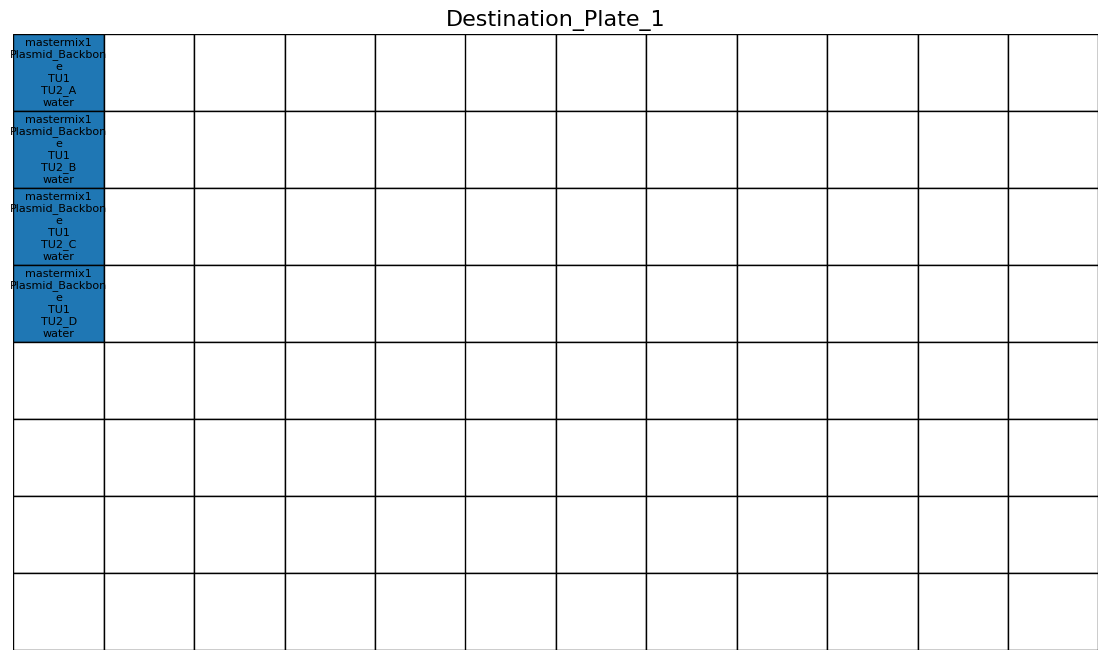

13:11:58 INFO assembly_designer.manager.manager: Destination plate plot saved to None


In [ ]:
# Plot Destination Plate
assembly_manager.plot_destination_plate(save_path="results/Assembly_Plan.png", 
                                        highlight_column="Promotor",  
                                        max_lines=6,
                                        exclude_keywords=["water", "mastermix"],
                                        color_palette=sns.color_palette("Blues", n_colors=8),
                                        cmap = "tab10",)

# Display the saved image
assembly_manager.plot_destination_plate(save_path=None)

<div><progress max="7" value="7"></progress> 100.00% [7/7 00:01&lt;00:00]</div>

13:08:43 INFO assembly_designer.manager.manager: Workflow simulation GIF written to results\Workflow_simulation.gif


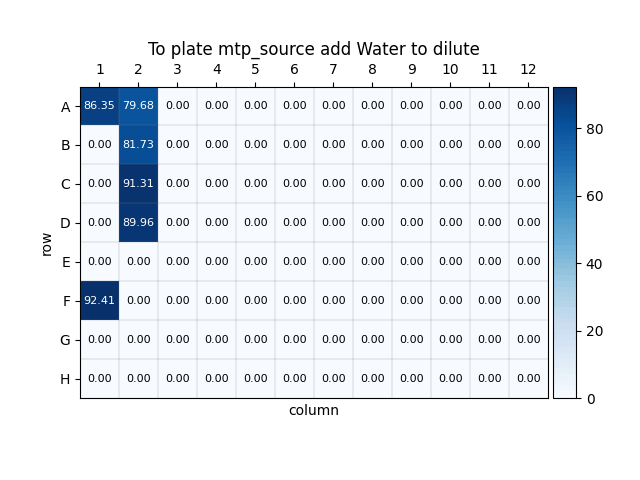

In [12]:
##### Check that the "# Initialize Workflow" cell is correctly set up before running the simulation, as it defines the workflow steps that will be executed.
##### Improper setup can lead to errors or an inaccurate simulation.
##### Ensure that the steps in the workflow match the operations you intend to simulate, and that the source and destination plates are correctly specified.

# Simulate the complete liquid handling process
assembly_manager.simulate_liquid_handling(fps=0.5, delay_frames=1)

<div><progress max="6" value="6"></progress> 100.00% [6/6 00:01&lt;00:00]</div>

13:08:44 INFO assembly_designer.mtp_manager.mtp_manager: Plate history GIF written to results\mtp_source.gif


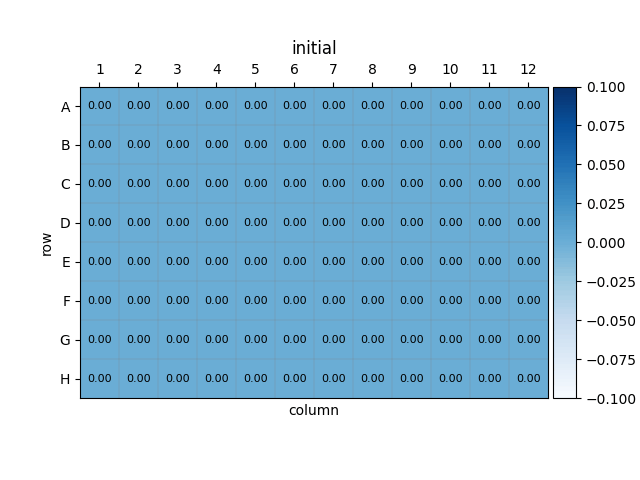

In [13]:
# Simulate plate history for the "mtp_source" plate (DNA dilution and Plasmidmix preparation)
mtp_manager.simulate_plate_history(mtp_manager.get_mtp("mtp_source"), fps=0.5, delay_frames=1)

<div><progress max="6" value="6"></progress> 100.00% [6/6 00:00&lt;00:00]</div>

13:08:45 INFO assembly_designer.mtp_manager.mtp_manager: Plate history GIF written to results\Destination_Plate_1.gif


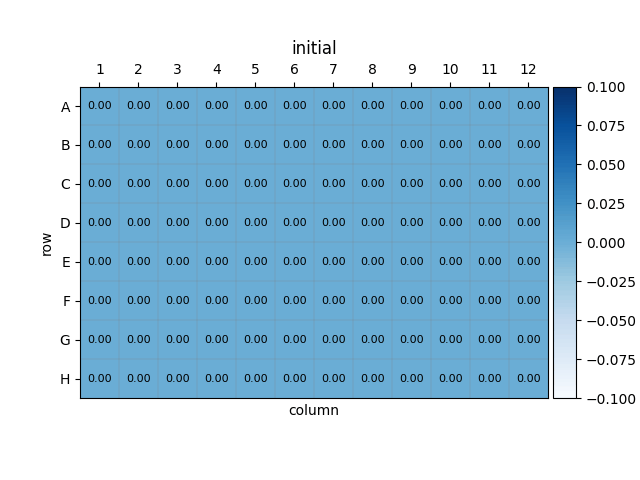

In [14]:
# Simulate plate history for the "mtp_destination" plate (final reaction assembly)
mtp_manager.simulate_plate_history(mtp_manager.get_mtp("mtp_destination"),fps=0.5, delay_frames=1)